## SBI Interactive Tutorial
---

In this interactive tutorial we demonstrate the usage of simulation based inference




In [1]:
import numpy as np
from getdist import plots, MCSamples
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.linalg import eigh
from sbi.inference import NLE, NPE
from sbi.utils import BoxUniform
import torch
from tqdm import tqdm

import jax
import jax_cosmo as jc
import jax.numpy as jnp
jax.config.update("jax_enable_x64", True)

## Notebook outline

We're going to calculate a SDDR with a simple Gaussian model

First, let's define some helper functions


## Plotting function

In [2]:
def triangle_plot(
    mc_samples,
    truth=None,
    params_to_plot=None,
    savefig=False,
    filename=None,
):
    # Triangle plot
    plt.close()
    with mpl.rc_context():
        # g = plots.getSubplotPlotter(width_inch=12)
        g = plots.getSubplotPlotter()
        g.settings.figure_legend_frame = False
        g.settings.alpha_filled_add = 0.6
        g.settings.axes_fontsize = 18
        g.settings.legend_fontsize = 18
        g.settings.lab_fontsize = 18
        if params_to_plot:
            g.triangle_plot(
                mc_samples, params=params_to_plot, filled_compare=True, normalized=True
            )
        else:
            g.triangle_plot(mc_samples, filled_compare=True, normalized=True)

        if truth is not None:
            g.add_param_markers(truth, color="black", ls="--")

        plt.subplots_adjust(hspace=0, wspace=0)

        if savefig:
            plt.savefig(filename, bbox_inches="tight")
        plt.show()
        
def plot_spectra(spectra):
    pass
    

## For a cosmic shear simulator, we need to first define some redshift bins

Here we are making use of smail distributions of widening width, defined as

$$
n(z)=z_a \exp{(z/z_0)^b}
$$

This defines for us the number density of "objects", in our case galaxies, in a given tomographic bin. 

We can think of each tomographic bin as a "shell" of observations going further away from us that we have banded together. 

We have split our mock galaxy survey into 5 tomographic bins.

In [3]:
nz1 = jc.redshift.smail_nz(1., 2.,  0.5)
nz2 = jc.redshift.systematic_shift(jc.redshift.smail_nz(1., 2., 0.6), 0.5)
nz3 = jc.redshift.systematic_shift(jc.redshift.smail_nz(1., 2., 0.8), 1.2)
nz4 = jc.redshift.systematic_shift(jc.redshift.smail_nz(1., 2., 1.0), 1.8)
nz5 = jc.redshift.systematic_shift(jc.redshift.smail_nz(1., 2., 1.2), 2.4)

nzs = [nz1, nz2, nz3, nz4, nz5]

## Let's also plot it to convince ourselves things are looking right

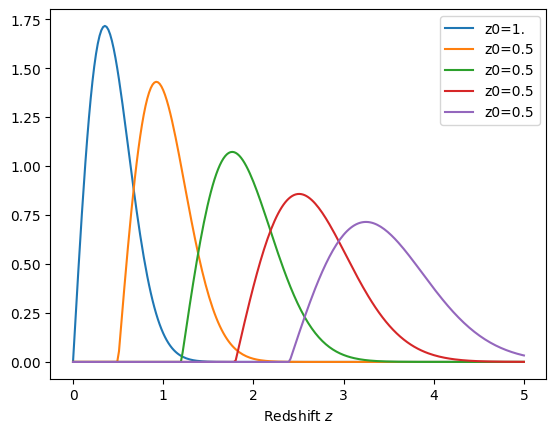

In [4]:
# And let's plot it
z = np.linspace(0,5,256)

# Redshift distributions are callable, and they return the normalized distribution
plt.plot(z, nz1(z), label='z0=1.')
plt.plot(z, nz2(z), label='z0=0.5')
plt.plot(z, nz3(z), label='z0=0.5')
plt.plot(z, nz4(z), label='z0=0.5')
plt.plot(z, nz5(z), label='z0=0.5')
plt.legend()
plt.xlabel('Redshift $z$');

## We also need to define some probes to describe what exactly we are observing

In [5]:
probes = [jc.probes.WeakLensing(nzs, sigma_e=0.26),]

## Lastly we also need to define the ell range that we want our power spectrum to go up to

In [6]:
ell = np.logspace(np.log10(2), np.log10(1000), 100)

In [7]:
cosmo_data = jc.Planck15()

In [8]:
cls = jc.angular_cl.angular_cl(cosmo_data, ell, probes)
noise_cls = jc.angular_cl.noise_cl(ell, probes)
cov = jc.angular_cl.gaussian_cl_covariance(ell, probes, cls, noise_cls, sparse=False)
cls_noise = jax.random.multivariate_normal(mean=jnp.concatenate(cls), cov=cov, key=jax.random.PRNGKey(42))

## Let's plot this all to see what our data vector looks like

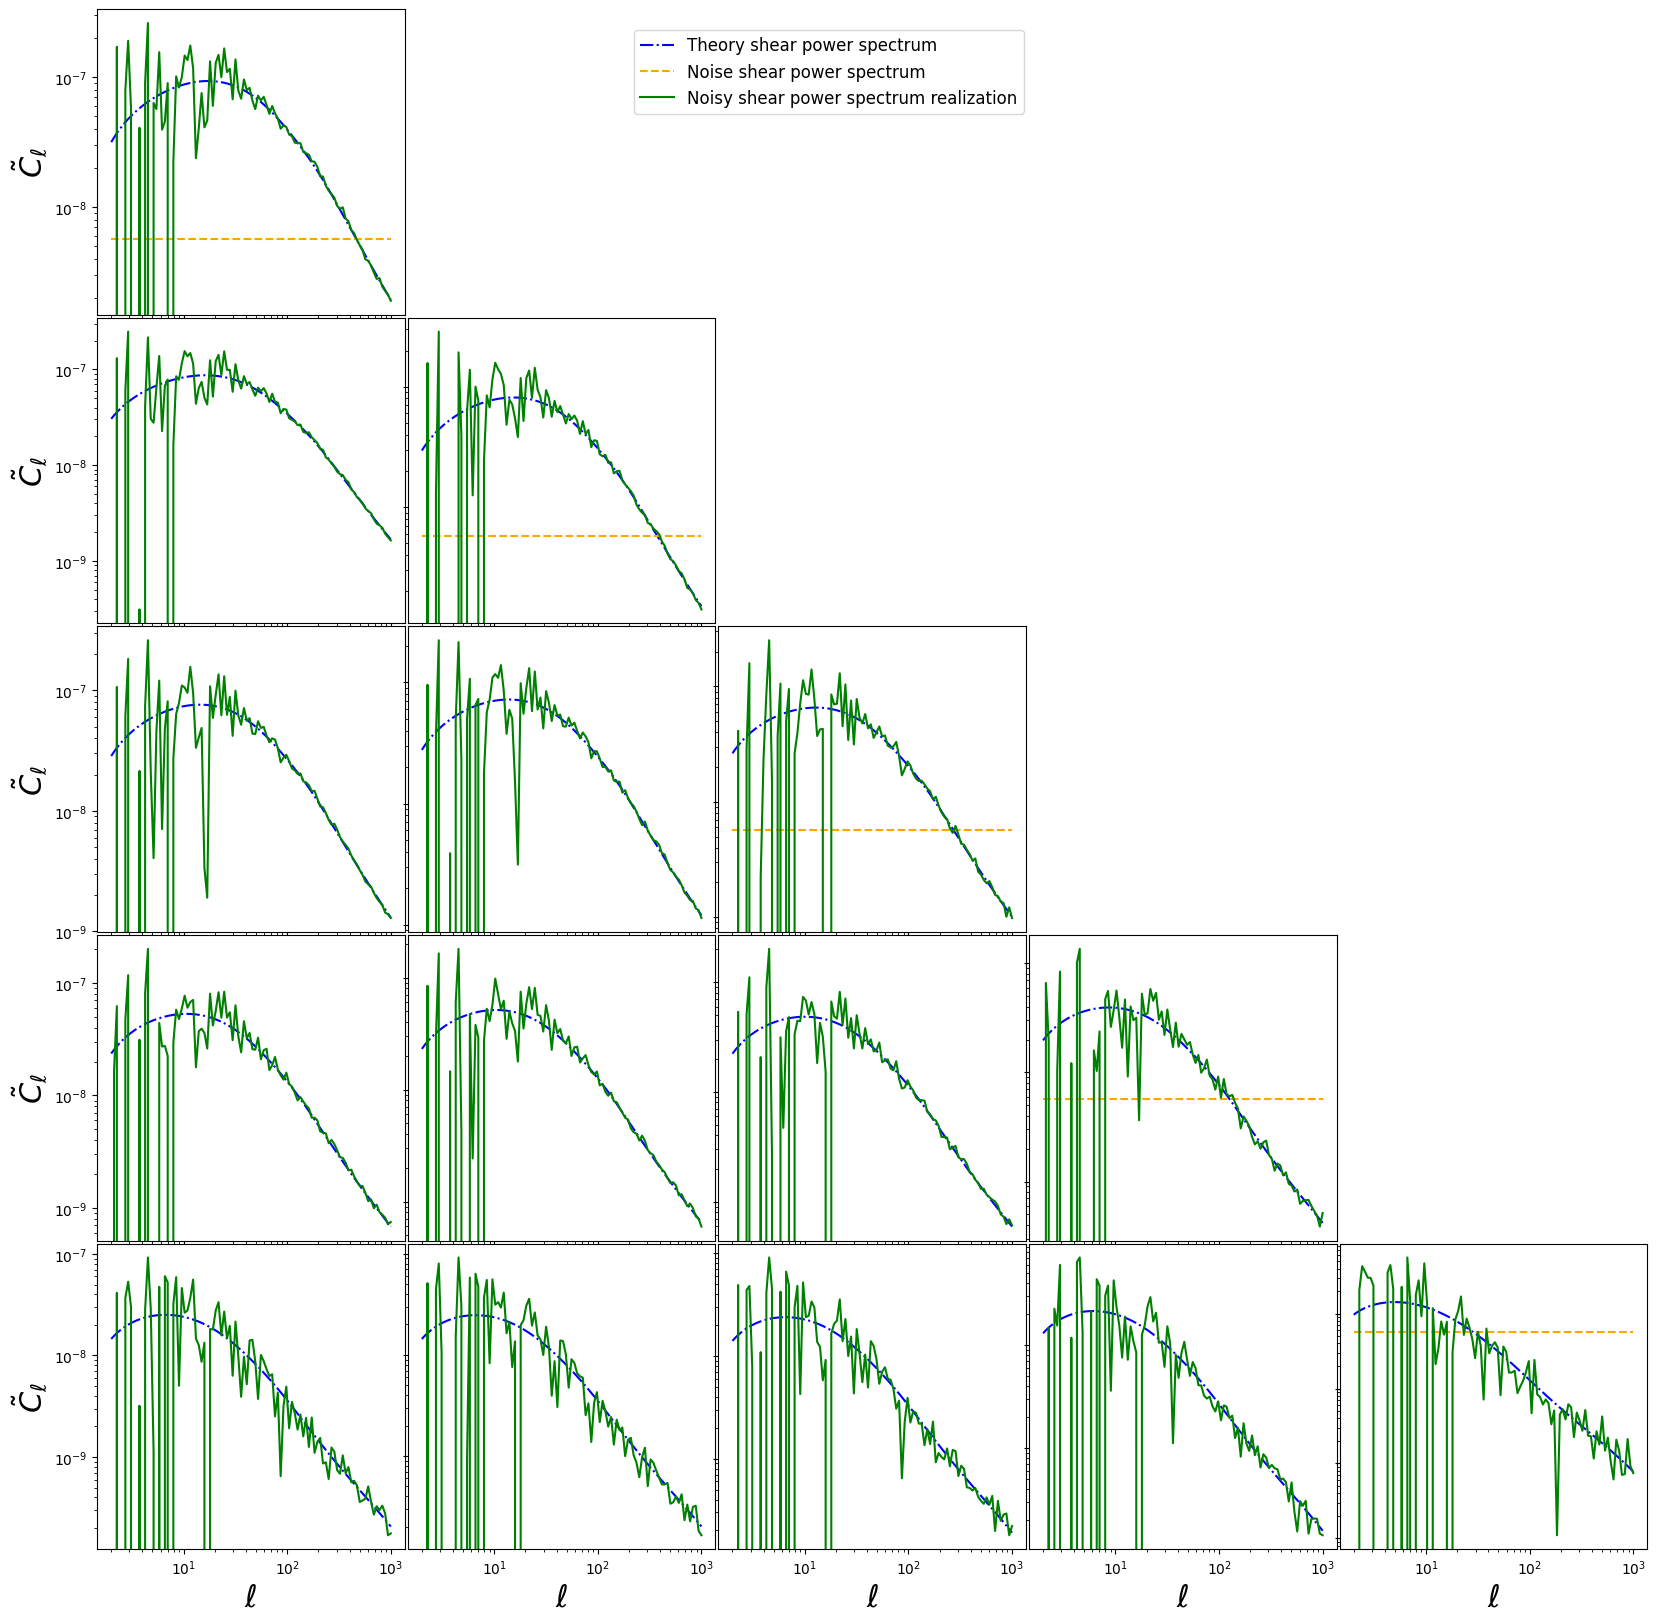

In [9]:
counter=0
fig, axs = plt.subplots(len(nzs), len(nzs), figsize=(20, 20))

cls_plot = cls[::-1]
noise_cls_plot = noise_cls[::-1]
cls_noise_plot = cls_noise.reshape(cls.shape)[::-1]

for i in range(0, len(nzs)):
    for j in range(0, len(nzs)):
        if i<j:
            axs[i, j].axis('off')
        else:
            axs[i, j].plot(ell, cls_plot[counter], c='blue', ls = '-.', label='Theory shear power spectrum')
            axs[i, j].plot(ell, noise_cls_plot[counter], c='orange', ls = '--', label='Noise shear power spectrum')
            axs[i, j].plot(ell, cls_noise_plot[counter], c='green', ls = '-', label='Noisy shear power spectrum realization')
            axs[i, j].set_xscale('log')
            axs[i, j].set_yscale('log')

            if i == len(nzs) - 1:
                axs[i, j].set_xlabel(r'$\ell$', fontsize=22)
            else:
                plt.setp(axs[i, j].get_xticklabels(), visible=False)
            
            if j == 0:
                axs[i, j].set_ylabel(r'$\tilde{C}_{\ell}$', fontsize=22)
            else:
                plt.setp(axs[i, j].get_yticklabels(), visible=False)

            counter += 1

plt.legend(bbox_to_anchor=(-1, 5), loc='upper right', fontsize=12)
plt.subplots_adjust(wspace=0.01, hspace=0.01)
plt.show()

## Let's also make a basic simulator

In [10]:
@jax.jit
def simulator(theta, key=jax.random.PRNGKey(42)):
    def single_sim(params, rng_key):
        cosmo = jc.Cosmology(
            sigma8=params[0],
            Omega_c=params[1],
            Omega_b=params[2],
            h=params[3],
            n_s=params[4],
            Omega_k=0.0,
            w0=-1.0,
            wa=0.0,
        )
        
        cls = jc.angular_cl.angular_cl(cosmo, ell, probes)
        cov = jc.angular_cl.gaussian_cl_covariance(ell, probes, cls, noise_cls, sparse=False)
        
        # Use JAX random generation instead of numpy
        return jax.random.multivariate_normal(rng_key, mean=jnp.concatenate(cls), cov=cov)

    # Split keys so each simulation gets a unique random seed
    keys = jax.random.split(key, theta.shape[0])
    
    # vmap the single simulation function over parameters and keys
    return jax.vmap(single_sim)(theta, keys)

In [11]:
def chunked_simulator(theta, chunk_size=100, key=jax.random.PRNGKey(42)):
    n_samples = theta.shape[0]
    n_chunks = int(np.ceil(n_samples / chunk_size))
    
    # Split the main key so each chunk gets a unique random state
    chunk_keys = jax.random.split(key, n_chunks)
    
    results = []
    for i in tqdm(range(n_chunks)):
        start = i * chunk_size
        end = min((i + 1) * chunk_size, n_samples)
        
        # Run the JIT-compiled simulator on the current batch
        batch_res = simulator(theta[start:end], key=chunk_keys[i])
        results.append(batch_res)
        
    return jnp.vstack(results)

## Set priors

Can be uniform or gaussian, here we use an uncorrelated Gaussian prior


In [12]:
params = ['sigma_8', 'Omega_c', 'Omega_b', 'h', 'n_s']

lower = torch.tensor([0.5, 0.1, 0.04, 0.64, 0.84])
upper = torch.tensor([1.2, 0.5, 0.06, 0.82, 1.10])

prior = BoxUniform(low=lower, high=upper)

## Let's use the same simulator to generate some simulated data with Gaussian nose

In [13]:
sim_samples_compression = prior.sample((2000,)).numpy()
simulated_data_compression = chunked_simulator(sim_samples_compression, chunk_size=10)

100%|██████████| 200/200 [00:56<00:00,  3.55it/s]


## Let's setup a compression method with CCA

Given the paired parameters and data,
$$
\begin{align}
\theta\in{\rm I\!R}^N,\;\;&\;\; X\in{\rm I\!R}^M \\
\end{align}
$$
we apply projection to both spaces.
$$
\begin{align}
\^{\theta}=U_\theta\theta\;,&\;\;\;\;U_\theta= \begin{pmatrix} w_1 & w_2 & \cdots & w_R \end{pmatrix}^T\\
\^{X}=U_XX\;,&\;\;\;\;U_X= \begin{pmatrix} v_1 & v_2 & \cdots & v_R \end{pmatrix}^T
\end{align}
$$
The vectors that form the compression matrix are solved via maximising the correlation in the projected space,
$$
w,\,v = \underset{w, v}{\operatorname{argmax}} \frac{w^{\top} \Sigma_{\theta X} v}{\sqrt{w^{\top} \Sigma_{\theta} w} \sqrt{v^{\top} \Sigma_{X} v}}
$$
where $\Sigma_{\theta X}$ is the cross covariance.
<br><br>Since we are seeking to compress the data vector $X$, we only need to find $v_1,...,v_R$. 

It would turn out that $R=min(N,M)$ due to the nature of the eigenvalue problem being solved when maximising the correlation.
$$
\Sigma_X^{-1}\Sigma_{X\theta}\Sigma_\theta^{-1}\Sigma_{\theta X} v = \lambda v
$$

In [14]:
n_params = sim_samples_compression.shape[1]

cca_cov = np.cov(sim_samples_compression.T, simulated_data_compression.T)
cp = cca_cov[:n_params,:n_params]
cd = cca_cov[n_params:,n_params:]
cpd = cca_cov[:n_params,n_params:]

# This 'cl' can be understood as the projection of 'cp' to data vector space
cl = cpd.T@np.linalg.inv(cp)@cpd

# As seen in the paper, this generalized eigenvalue problem is equivalent to CCA
# but is more numerically stable as 'cd' and 'cd-cl' are both invertible.
# This problem is motivated as mutual information maximization under Gaussian linear model assumptions
evals, evecs = eigh(cd, cd - cl)

# In the context of the CCA, only min( dim(param), dim(data vector)) components are real and the rest are noise. 
evals = evals[::-1][:n_params]
evecs = evecs[:,::-1][:,:n_params]

## Now let's make a mock data vector with our simulator and compress is

In [15]:
truth = [cosmo_data.sigma8, cosmo_data.Omega_c, cosmo_data.Omega_b, cosmo_data.h, cosmo_data.n_s]

In [29]:
mock_theta = torch.tensor([truth], dtype=torch.float32)
mock_obs = chunked_simulator(mock_theta.numpy(), chunk_size=1)[0]
compressed_obs = torch.as_tensor(np.asarray(mock_obs@evecs).copy(), dtype=torch.float32)

100%|██████████| 1/1 [00:00<00:00, 1112.55it/s]


## Now let's do some SBI with NLE
An overview of the NLE method is as follows:
1. Define prior $\pi(\theta)$
2. Introduce proposal likelihood $q_\phi(x|\theta)$ represented by a conditional normalising flow network.
3. Obtain training data $(x,\theta)$ using $\theta\sim \pi(\theta)$
4. Train $q_\phi(x|\theta)$ to approximate the true likelihood $p(x|\theta)$ with respect to the loss. $D_{KL}(\,p(x|\theta)\,||\,q_\phi(x|\theta)\,)$.
5. For sequential, repeat steps 3 and 4 but change the distribution we draw simulations from 

Here are some references:
1. Sequential neural likelihood: Fast likelihood-free inference with autoregressive flows (Papamarkaios, Sterratt & Murray 2019)
2. Fast likelihood-free cosmology with neural density estimators and active learning (Alsing, Feeney, Charnock, Wandelt 2019)
3. Flexible and efficient simulation-based inference for models of decision-making (Boelts, Lueckmann, Gao, Macke 2022)
4. KiDS-SBI: Simulation-based inference analysis of KiDS-1000 cosmic shear (von Wietersheim-Kramsta, Lin, Tessore, Joachimi, Loureiro, Reischke, Wright 2024)

In [ ]:
num_sims = 1000
num_rounds = 5
nle_inference = NLE(prior)
nle_proposal = prior

In [31]:
for _ in range(num_rounds):
    theta = nle_proposal.sample((num_sims,))
    x = chunked_simulator(theta.detach().numpy(), chunk_size=10)
    compressed_x = np.asarray(x)@evecs # This is the step where we apply the compression from above to our simulated data
    compressed_x = torch.tensor(compressed_x, dtype=torch.float32)
    _ = nle_inference.append_simulations(theta, compressed_x).train()
    nle_posterior = nle_inference.build_posterior().set_default_x(compressed_obs)
    nle_proposal = nle_posterior

100%|██████████| 100/100 [00:30<00:00,  3.31it/s]


 Neural network successfully converged after 23 epochs.

/Users/kiyam/Code/academia/sbi_tutorial/.venv/lib/python3.12/site-packages/sbi/inference/posteriors/mcmc_posterior.py:126: UserWarning: The default value for thinning in MCMC sampling has been changed from 10 to 1. This might cause the results differ from the last benchmark.
  thin = _process_thin_default(thin)


Generating 20 MCMC inits via resample strategy:   0%|          | 0/20 [00:00<?, ?it/s]

Running vectorized MCMC with 20 chains:   0%|          | 0/6000 [00:00<?, ?it/s]

...

 Neural network successfully converged after 21 epochs.

Generating 20 MCMC inits via resample strategy:   0%|          | 0/20 [00:00<?, ?it/s]

Running vectorized MCMC with 20 chains:   0%|          | 0/6000 [00:00<?, ?it/s]

100%|██████████| 100/100 [00:23<00:00,  4.17it/s]


 Neural network successfully converged after 48 epochs.

## Get some posterior samples with emcee


In [32]:
nle_posterior_theta = nle_posterior.sample((20000,), x=compressed_obs, num_chains=100)

Generating 100 MCMC inits via resample strategy:   0%|          | 0/100 [00:00<?, ?it/s]

Running vectorized MCMC with 100 chains:   0%|          | 0/45000 [00:00<?, ?it/s]

## Let's also calculate the log probs for these samples

In [33]:
nle_posterior_samples = nle_posterior_theta.detach().numpy()
nle_posterior_log_probs = nle_posterior.potential(nle_posterior_theta.detach(), x=torch.tensor(compressed_obs, dtype=torch.float32)).numpy()

/var/folders/6n/hfj2qpk95wl0p60xd9fg40y00000gn/T/ipykernel_11726/3446126637.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  nle_posterior_log_probs = nle_posterior.potential(nle_posterior_theta.detach(), x=torch.tensor(compressed_obs, dtype=torch.float32)).numpy()


## Let's also do the same thing with NPE
An overview of the NPE method is as follows:
1. Define prior $\pi(\theta)$
2. Introduce proposal distribution $q_\phi(x|\theta)$ represented by a conditional normalising flow network.
3. Obtain training data $(x,\theta)$ using $\theta\sim \pi(\theta)$
4. Train $q_\phi(\theta|x)$ to approximate the true posterior $p(\theta|x)$ with respect to the loss. $D_{KL}(\,p(\theta|x)\,||\,q_\phi(\theta|x)\,)$.
5. For sequential, repeat steps 3 and 4 but change the distribution we draw simulations from 

Here are some references:
1. Fast ε-free Inference of Simulation Models with Bayesian Conditional Density Estimation by Papamakarios & Murray (NeurIPS 2016)
2. Flexible statistical inference for mechanistic models of neural dynamics by Lueckmann, Goncalves, Bassetto, Öcal, Nonnenmacher & Macke (NeurIPS 2017)
3. Automatic posterior transformation for likelihood-free inference by Greenberg, Nonnenmacher & Macke (ICML 2019)
4. BayesFlow: Learning complex stochastic models with invertible neural networks by Radev, S. T., Mertens, U. K., Voss, A., Ardizzone, L., & Köthe, U. (IEEE transactions on neural networks and learning systems 2020)
5. Truncated proposals for scalable and hassle-free simulation-based inference by Deistler, Goncalves & Macke (NeurIPS 2022)
6. Flow matching for scalable simulation-based inference by Dax, M., Wildberger, J., Buchholz, S., Green, S. R., Macke, J. H., & Schölkopf, B. (NeurIPS, 2023)
7. Compositional Score Modeling for Simulation-Based Inference by Geffner, T., Papamakarios, G., & Mnih, A. (ICML 2023)

In [34]:
npe_inference = NPE(prior)
npe_proposal = prior

In [35]:
for _ in range(num_rounds):
    theta = npe_proposal.sample((num_sims,))
    x = chunked_simulator(theta.detach().numpy(), chunk_size=10)
    compressed_x = np.asarray(x)@evecs # This is the step where we apply the compression from above to our simulated data
    compressed_x = torch.tensor(compressed_x, dtype=torch.float32)
    _ = npe_inference.append_simulations(theta, compressed_x, proposal=npe_proposal).train()
    npe_posterior = npe_inference.build_posterior().set_default_x(compressed_obs)
    npe_proposal = npe_posterior

100%|██████████| 100/100 [00:25<00:00,  3.86it/s]


 Neural network successfully converged after 168 epochs.

  0%|          | 0/1000 [00:00<?, ?it/s]

100%|██████████| 100/100 [00:27<00:00,  3.60it/s]


Using SNPE-C with atomic loss
 Neural network successfully converged after 35 epochs.

...

100%|██████████| 100/100 [00:24<00:00,  4.08it/s]


Using SNPE-C with atomic loss
 Neural network successfully converged after 31 epochs.

  0%|          | 0/1000 [00:00<?, ?it/s]

100%|██████████| 100/100 [00:24<00:00,  4.01it/s]


Using SNPE-C with atomic loss
 Neural network successfully converged after 22 epochs.

In [36]:
npe_posterior_theta = npe_posterior.sample((20000,), x=compressed_obs)

  0%|          | 0/20000 [00:00<?, ?it/s]

In [37]:
npe_posterior_samples = npe_posterior_theta.detach().numpy()
npe_posterior_log_probs = npe_posterior.potential(npe_posterior_theta.detach(), x=torch.tensor(compressed_obs, dtype=torch.float32)).numpy()

/var/folders/6n/hfj2qpk95wl0p60xd9fg40y00000gn/T/ipykernel_11726/3451352399.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  npe_posterior_log_probs = npe_posterior.potential(npe_posterior_theta.detach(), x=torch.tensor(compressed_obs, dtype=torch.float32)).numpy()


## Plot!


In [38]:
param_labels = [r'\sigma_8', r'\Omega_c', r'\Omega_b', r'h', r'n_s']
truth = [cosmo_data.sigma8, cosmo_data.Omega_c, cosmo_data.Omega_b, cosmo_data.h, cosmo_data.n_s]
truth_marker = dict(zip(params, truth))

### Make the getdist MC objects

In [41]:
nle_samples = MCSamples(
    samples=nle_posterior_samples,
    loglikes=nle_posterior_log_probs,
    names=params,
    labels=param_labels,
    label="NLE SBI",
    sampler="mcmc",
)

npe_samples = MCSamples(
    samples=npe_posterior_samples,
    loglikes=npe_posterior_log_probs,
    names=params,
    labels=param_labels,
    label="NPE SBI",
    sampler="mcmc",
)

Removed no burn in
Removed no burn in


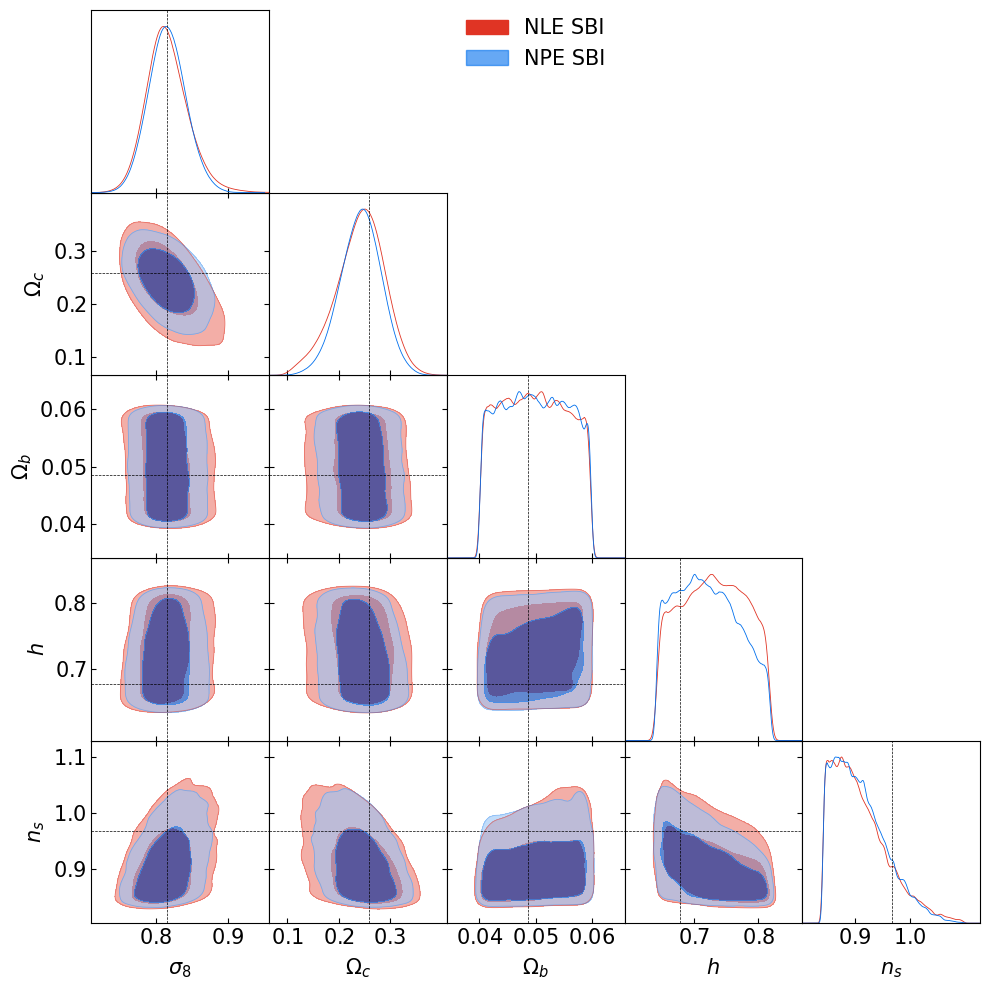

In [42]:
triangle_plot(
    [nle_samples, npe_samples],
    truth=truth_marker)

## So whilst we have a posterior, we should do a coverage test
We will make use of the TARP method that calculates the coverage from samples.
This test checks wether the coverage probability matches to a given credibility interval.
In the practical context of SBI, it checks whether the neural surrogate likelihood or posterior is well trained across the prior volume.

References:
1. TARP by Lemos, Coogan, Hezaveh & Perreault-Levasseur (ICML 2023)

In [43]:
from sbi.diagnostics import run_tarp, check_tarp
from sbi.analysis.plot import plot_tarp

100%|██████████| 20/20 [00:03<00:00,  6.57it/s]
/Users/kiyam/Code/academia/sbi_tutorial/.venv/lib/python3.12/site-packages/sbi/diagnostics/tarp.py:75: UserWarning: Using non-batched sampling. Depending on the number of different xs ( 200) and the number of parallel workers 1, this might take a lot of time.
  posterior_samples = get_posterior_samples_on_batch(
Sampling 200 times (1000,) posterior samples.: 100%|██████████| 200/200 [26:35<00:00,  7.98s/it]

-0.36600035429000854 Should be close to 0
0.9999999953860058 Should be larger than 0.05


(<Figure size 600x600 with 1 Axes>,
 <Axes: xlabel='Credibility Level $\\alpha$', ylabel='Expected Coverage Probability'>)

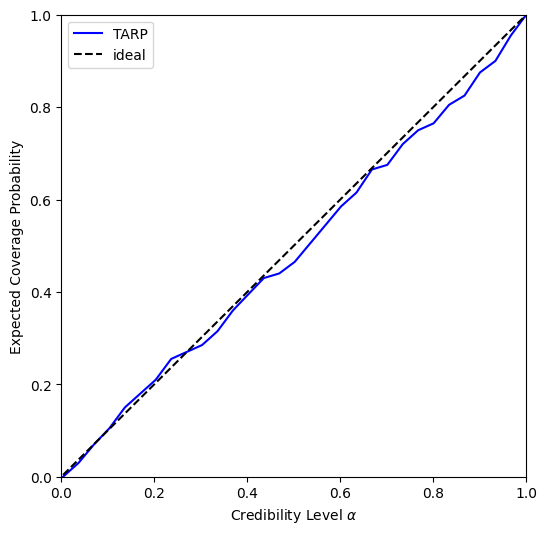

In [ ]:
num_tarp_samples = 200  # choose a number of sbc runs, should be ~100s
# generate ground truth parameters and corresponding simulated observations for SBC.
tarp_samples = prior.sample((num_tarp_samples,))
prior_predictives = chunked_simulator(tarp_samples.detach().numpy(), chunk_size=10)
compressed_predictives = np.asarray(prior_predictives) @ evecs  # This is the step where we apply the compression from above to our simulated data
compressed_predictives = torch.tensor(compressed_predictives, dtype=torch.float32)

# the tarp method returns the ECP values for a given set of alpha coverage levels.
ecp, alpha = run_tarp(
    tarp_samples,
    compressed_predictives,
    nle_posterior,
    references=None,  # will be calculated automatically.
    num_posterior_samples=1000,
    use_batched_sampling=False,  # `True` can give speed-ups, but can cause memory issues.
)
# Similar to SBC, we can check then check whether the distribution of ecp is close to
# that of alpha.
atc, ks_pval = check_tarp(ecp, alpha)
print(atc, "Should be close to 0")
print(ks_pval, "Should be larger than 0.05")

plot_tarp(ecp, alpha)

![COVERAGE](images/coverage_bias.png)